# 可选实验 - 简单神经网络
在本实验中，我们将使用 TensorFlow 构建一个小型神经网络。
   <center> <img  src="../work/images/C2_W1_CoffeeRoasting.png" width="400" />   <center/>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from lab_utils_common import dlc
from lab_coffee_utils import load_coffee_data, plt_roast, plt_prob, plt_layer, plt_network, plt_output_unit
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)


## 数据集

In [3]:
X,Y = load_coffee_data();
print(X.shape, Y.shape)

(200, 2) (200, 1)


下面绘制咖啡烘焙数据。两个特征分别是摄氏温度和以分钟计的烘焙时长。[在家烘焙咖啡](https://www.merchantsofgreencoffee.com/how-to-roast-green-coffee-in-your-oven/)建议，时长最好保持在 12 到 15 分钟之间，温度应在 175 到 260 摄氏度之间。当然，温度越高，所需时间应越短。

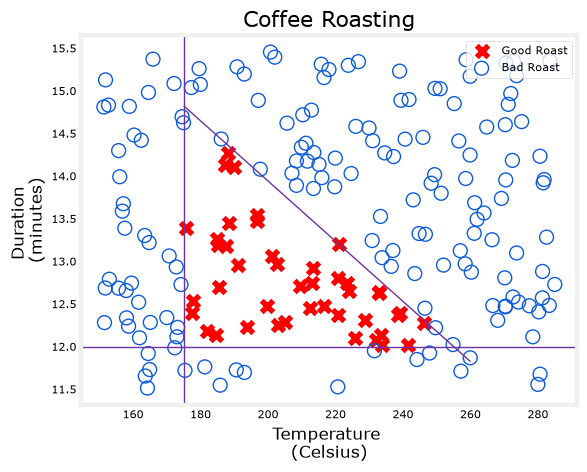

In [5]:
plt_roast(X,Y)

### 归一化数据
如果数据经过归一化，权重与数据的拟合过程（反向传播，将在下周课程中介绍）会更快。这与您在课程 1 中使用的过程相同：对数据中的各个特征进行归一化，使其范围相近。
下面的过程使用 Keras 的[归一化层](https://keras.io/api/layers/preprocessing_layers/numerical/normalization/)，步骤如下：
- 创建一个“归一化层”。请注意，按这里的用法，它并不是模型中的一层；
- 对数据执行“adapt”。这会学习数据集的均值和方差，并在内部保存这些值；
- 对数据进行归一化。  
对于今后使用已训练模型的任何数据，都必须应用归一化。

In [6]:
print(f"Temperature Max, Min pre normalization: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):0.2f}")
print(f"Duration    Max, Min pre normalization: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):0.2f}")
norm_l = tf.keras.layers.Normalization(axis=-1)
norm_l.adapt(X)  # learns mean, variance
Xn = norm_l(X)
print(f"Temperature Max, Min post normalization: {np.max(Xn[:,0]):0.2f}, {np.min(Xn[:,0]):0.2f}")
print(f"Duration    Max, Min post normalization: {np.max(Xn[:,1]):0.2f}, {np.min(Xn[:,1]):0.2f}")

Temperature Max, Min pre normalization: 284.99, 151.32
Duration    Max, Min pre normalization: 15.45, 11.51
Temperature Max, Min post normalization: 1.66, -1.69
Duration    Max, Min post normalization: 1.79, -1.70


平铺/复制数据以增大训练集规模，并减少训练轮数。

In [7]:
Xt = np.tile(Xn,(1000,1))
Yt= np.tile(Y,(1000,1))   
print(Xt.shape, Yt.shape)   

(200000, 2) (200000, 1)


## TensorFlow 模型

### 模型
   <center> <img  src="../work/images/C2_W1_RoastingNetwork.PNG" width="200" />   <center/>  
让我们构建课程中介绍的“咖啡烘焙网络”。它包含两个使用 sigmoid 激活函数的层，如下所示：

In [9]:
tf.random.set_seed(1234)  # applied to achieve consistent results
model = Sequential(
    [
        tf.keras.Input(shape=(2,)),
        Dense(3, activation='sigmoid', name = 'layer1'),
        Dense(1, activation='sigmoid', name = 'layer2')
     ]
)

>**注 1：** `tf.keras.Input(shape=(2,)),` 指定输入的预期形状。这使 TensorFlow 能够在此时确定权重和偏置参数的大小。在探索 TensorFlow 模型时，这很有用。实际使用中可以省略此语句，TensorFlow 会在 `model.fit` 语句中指定输入数据时确定网络参数的大小。  
>**注 2：** 在最后一层中加入 sigmoid 激活并不被视为最佳实践。更好的做法是将其纳入损失函数，这样可提高数值稳定性。后续实验会对此进行更详细的说明。

`model.summary()` 提供了网络的描述：

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                       │ (None, 3)                   │               9 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ layer2 (Dense)                       │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

摘要中显示的参数数量，对应于下面所示权重数组和偏置数组中的元素数量。

In [11]:
L1_num_params = 2 * 3 + 3   # W1 parameters  + b1 parameters
L2_num_params = 3 * 1 + 1   # W2 parameters  + b2 parameters
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params  )

L1 params =  9 , L2 params =  4


让我们检查 TensorFlow 实例化的权重和偏置。权重 $W$ 的大小应为（输入特征数, 层中单元数），而偏置 $b$ 的大小应与层中的单元数相匹配：
- 在包含 3 个单元的第一层中，我们预期 W 的大小为 (2,3)，而 $b$ 应包含 3 个元素。
- 在包含 1 个单元的第二层中，我们预期 W 的大小为 (3,1)，而 $b$ 应包含 1 个元素。

In [12]:
W1, b1 = model.get_layer("layer1").get_weights()
W2, b2 = model.get_layer("layer2").get_weights()
print(f"W1{W1.shape}:\n", W1, f"\nb1{b1.shape}:", b1)
print(f"W2{W2.shape}:\n", W2, f"\nb2{b2.shape}:", b2)

W1(2, 3):
 [[-0.06  0.63 -0.49]
 [ 0.4   0.22  0.6 ]] 
b1(3,): [0. 0. 0.]
W2(3, 1):
 [[-0.48]
 [ 1.19]
 [ 0.81]] 
b2(1,): [0.]


以下语句将在第 2 周详细说明。现在只需知道：
- `model.compile` 语句定义损失函数，并指定编译优化配置。
- `model.fit` 语句运行梯度下降，并将权重拟合到数据。

In [13]:
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
)

model.fit(
    Xt,Yt,            
    epochs=10,
)

Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 0.1973
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0358
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0168
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0110
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0077
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0056
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0041
Epoch 8/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0030
Epoch 9/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0022
Epoch 10/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 0.0017


#### 更新后的权重
拟合后，权重已更新：

In [15]:
W1, b1 = model.get_layer("layer1").get_weights()
W2, b2 = model.get_layer("layer2").get_weights()
print("W1:\n", W1, "\nb1:", b1)
print("W2:\n", W2, "\nb2:", b2)

W1:
 [[14.13 13.91 -0.04]
 [11.83  0.35 -9.38]] 
b1: [  1.84  14.57 -11.68]
W2:
 [[-47.03]
 [ 42.14]
 [-49.59]] 
b2: [-13.01]


接下来，我们将加载之前一次训练运行所保存的权重。这是为了确保此 Notebook 能够适应 TensorFlow 随时间发生的变化。不同的训练运行可能会产生略有不同的结果，而下面的讨论针对某个特定解。你可以随时注释掉此单元格并重新运行 Notebook，观察其中的差异。

In [16]:
W1 = np.array([
    [-8.94,  0.29, 12.89],
    [-0.17, -7.34, 10.79]] )
b1 = np.array([-9.87, -9.28,  1.01])
W2 = np.array([
    [-31.38],
    [-27.86],
    [-32.79]])
b2 = np.array([15.54])
model.get_layer("layer1").set_weights([W1,b1])
model.get_layer("layer2").set_weights([W2,b2])

### 预测
<img align="left" src="../work/images/C2_W1_RoastingDecision.PNG"     style=" width:380px; padding: 10px 20px; " >

训练好模型后，就可以用它进行预测。回顾一下，模型的输出是一个概率；在本例中，是烘焙良好的概率。要作出判断，必须将该概率与阈值比较。本例将使用 0.5。

先创建输入数据。模型需要一个或多个样本，样本位于矩阵的各行。在本例中有两个特征，因此矩阵形状为 (m,2)，其中 m 是样本数量。
请记住，我们已经对输入特征进行了归一化，所以测试数据也必须归一化。  
要进行预测，请应用 `predict` 方法。

In [18]:
X_test = np.array([
    [200,13.9],  # postive example
    [200,17]])   # negative example
X_testn = norm_l(X_test)
predictions = model.predict(X_testn)
print("predictions = \n", predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
predictions = 
 [[9.63e-01]
 [3.03e-08]]


#### 轮次与批次
在上面的 `compile` 语句中，`epochs` 的数量被设置为 10。这表示在训练期间应对整个数据集应用 10 次。训练时，你会看到类似下面这样的进度输出：
```
Epoch 1/10
6250/6250 [==============================] - 6s 910us/step - loss: 0.1782
```
第一行 `Epoch 1/10` 表示模型当前正在运行哪个轮次。为提高效率，训练数据集被划分为多个“批次”。TensorFlow 中的默认批次大小为 32。扩展后的数据集中有 200000 个样本，也就是 6250 个批次。第二行的记号 `6250/6250 [====` 表示已执行到哪个批次。

为了将概率转换为决策，我们应用一个阈值：

In [19]:
yhat = np.zeros_like(predictions)
for i in range(len(predictions)):
    if predictions[i] >= 0.5:
        yhat[i] = 1
    else:
        yhat[i] = 0
print(f"decisions = \n{yhat}")

decisions = 
[[1.]
 [0.]]


可以用更简洁的方式完成：

In [20]:
yhat = (predictions >= 0.5).astype(int)
print(f"decisions = \n{yhat}")

decisions = 
[[1]
 [0]]


## 层函数
让我们检查各单元的函数，以确定它们在咖啡烘焙决策中的作用。我们将针对输入（时长、温度）的所有取值绘制每个节点的输出。每个单元都是一个逻辑函数，其输出范围为零到一。图中的阴影表示输出值。
> 注意：在实验中，我们通常从零开始编号，而课程可能从 1 开始编号。

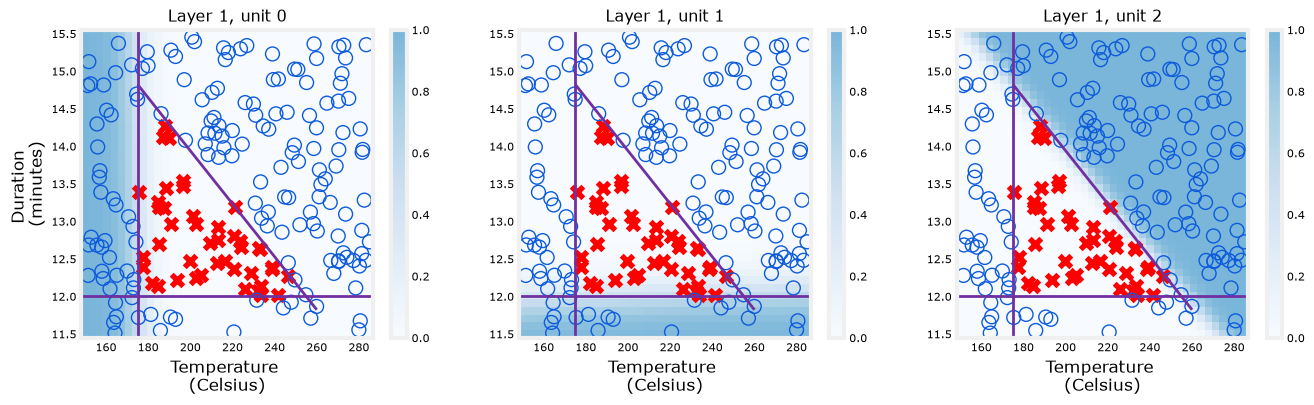

In [21]:
plt_layer(X,Y.reshape(-1,),W1,b1,norm_l)

阴影显示每个单元负责不同的“烘焙不佳”区域。温度过低时，单元 0 的值较大；时长过短时，单元 1 的值较大；时间/温度组合不佳时，单元 2 的值较大。值得注意的是，网络通过梯度下降过程自行学到了这些函数。它们与人类为做出相同决策而可能选择的函数非常相似。

最后一层的函数图像较难可视化。它的输入是第一层的输出。我们知道第一层使用 sigmoid，因此其输出范围在 0 和 1 之间。可以创建三维图，计算三个输入的所有可能组合对应的输出，如下所示。上图中，较高的输出值对应“烘焙不佳”的区域。下图中，最大输出出现在三个输入值都较小的区域，这些区域对应“烘焙良好”的情况。

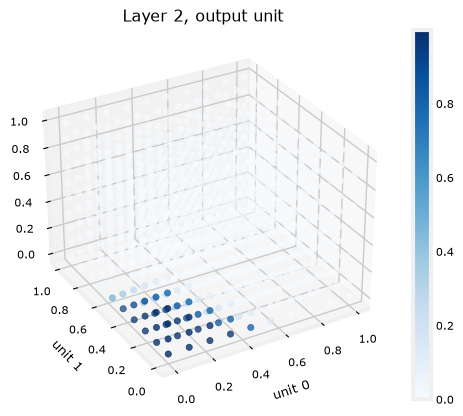

In [23]:
plt_output_unit(W2,b2)

最后一张图展示了整个网络的运行过程。  
左图是最后一层的原始输出，以蓝色阴影表示；其上叠加了以 X 和 O 表示的训练数据。  
右图是经过决策阈值处理后的网络输出。这里的 X 和 O 对应网络做出的决策。  
以下内容运行需要一些时间

In [ ]:
netf= lambda x : model.predict(norm_l(x))
plt_network(X,Y,netf)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━

## 恭喜！
你已经在 TensorFlow 中构建了一个小型神经网络。
该网络通过将决策分配给多个单元，展示了神经网络处理复杂决策的能力。